# LoraF Results and Visualization
This notebook provides a comprehensive view of the LoraE model performance across various scenarios and adaptive behaviors.

In [51]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Paths
model_name = 'LoraF_invi_visi_rank_1'
model_dir = f'trained_models/{model_name}/test/'
video_root = 'visualizations'
master_csv = 'result/master_summary.csv'
current_exp_id = '0' # Set to your exp_id (e.g. '1') or None for default
show_videos = False # Set to False to disable video rendering and speed up the notebook

scenarios = [
    'all_ignorant',
    'all_aware',
    'ignorant_to_aware_step25',
    'mixed_5050',
    'cluster_aware_ignorant',
]

def _scenario_filename_prefix(scenario):
    # Legacy 'seperate_*' scenarios are stored on disk with the 'seperate_'
    # filename prefix; the scenarios list above drops it for cleaner display.
    # Newer scenarios (e.g. cluster_aware_ignorant) are stored under their
    # own name as-is.
    if scenario.startswith('cluster_'):
        return scenario
    return f'seperate_{scenario}'


# Fast-path data source: rl/evaluation.py maintains a small aggregate
# `all_evaluations.json` (<200 KB total) keyed by exp_id, with the
# `summary` dict for every test run. Reading that single file replaces
# parsing dozens of multi-GB per-run JSONs.
_ALL_EVAL_PATH = os.path.join(model_dir, 'all_evaluations.json')
# Per-file mtime cache (fallback path, used if a key is missing from the
# aggregate — e.g. very old runs predating all_evaluations.json).
_SUMMARY_CACHE_PATH = os.path.join(model_dir, '_summary_cache.json')


def _load_json(path):
    if not os.path.exists(path):
        return {}
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError):
        return {}


def _save_summary_cache(cache):
    try:
        with open(_SUMMARY_CACHE_PATH, 'w') as f:
            json.dump(cache, f)
    except OSError as e:
        print(f"Warning: could not write summary cache to {_SUMMARY_CACHE_PATH}: {e}")


def _summary_from_big_json(filepath, cache):
    # Slow fallback: parse the full multi-GB per-run JSON. Result is
    # cached by (filename, mtime) so this only runs once per file version.
    if not os.path.exists(filepath):
        return None
    filename = os.path.basename(filepath)
    mtime = os.path.getmtime(filepath)
    entry = cache.get(filename)
    if entry is not None and entry.get('mtime') == mtime:
        return entry.get('summary')
    print(f"  [slow] parsing {filename} ({os.path.getsize(filepath)/1e9:.2f} GB) — cache miss")
    with open(filepath, 'r') as f:
        data = json.load(f)
    summary = data.get('summary', {})
    cache[filename] = {'mtime': mtime, 'summary': summary}
    return summary


def load_results(scenarios, behaviors, exp_id=None):
    results = []
    exp_suffix = f"_exp{exp_id}" if exp_id else ""
    aggregate = _load_json(_ALL_EVAL_PATH)
    cache = _load_json(_SUMMARY_CACHE_PATH)
    cache_size_before = len(cache)

    for scenario in scenarios:
        prefix = _scenario_filename_prefix(scenario)
        for behavior in behaviors:
            key = f"{prefix}_{behavior}{exp_suffix}"
            entry = aggregate.get(key)
            summary = entry.get('summary') if isinstance(entry, dict) else None

            if summary is None:
                # Fall back to parsing the per-run big JSON (slow, cached).
                filepath = os.path.join(model_dir, f"{key}.json")
                if not os.path.exists(filepath):
                    print(f"File not found: {filepath}")
                    continue
                summary = _summary_from_big_json(filepath, cache)
                if summary is None:
                    continue

            if summary.get('num_episodes', 0) >= 500:
                tp = summary.get('tp', 0) or 0
                tn = summary.get('tn', 0) or 0
                fp = summary.get('fp', 0) or 0
                fn = summary.get('fn', 0) or 0
                total_aw = tp + tn + fp + fn
                # AwAcc / AwF1 from the shadow-eval counters logged by
                # rl/evaluation.py. NaN when the behaviour didn't run the
                # predictor in shadow mode (no TP/TN/FP/FN recorded).
                if total_aw > 0:
                    aw_acc = (tp + tn) / total_aw
                    aw_prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    aw_rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    aw_f1 = (2 * aw_prec * aw_rec / (aw_prec + aw_rec)
                             if (aw_prec + aw_rec) > 0 else 0.0)
                else:
                    aw_acc = aw_f1 = float('nan')
                _n = summary.get('num_episodes', 0) or 0
                _sr = summary.get('success_rate')
                _pl = summary.get('avg_path_length')
                _pl_std = summary.get('std_path_length')
                _sr_ci = _wilson_ci_half(_sr, _n) if _sr is not None else float('nan')
                _pl_ci = _pl_ci_half(_pl_std, _n)
                _itr     = summary.get('avg_intrusion_ratio_pct')
                _itr_std = summary.get('std_intrusion_ratio_pct')
                _sd      = summary.get('avg_min_social_distance')
                _sd_std  = summary.get('std_min_social_distance')
                _itr_ci  = _pl_ci_half(_itr_std, _n)
                _sd_ci   = _pl_ci_half(_sd_std, _n)
                results.append({
                    'Scenario': scenario,
                    'Behavior': behavior,
                    'SR': _sr,
                    'SR_CI': _sr_ci,
                    'CR': summary.get('collision_rate'),
                    'TR': summary.get('timeout_rate'),
                    'NavTime': summary.get('avg_nav_time'),
                    'PathLen': _pl,
                    'PL_CI': _pl_ci,
                    'ITR': _itr,
                    'ITR_CI': _itr_ci,
                    'SD': _sd,
                    'SD_CI': _sd_ci,
                    'Uncertainty': summary.get('avg_uncertainty'),
                    'AvgLoRA': summary.get('avg_lora_scale', 'N/A'),
                    'AwAcc': aw_acc,
                    'AwF1': aw_f1,
                    'TP': tp,
                    'TN': tn,
                    'FP': fp,
                    'FN': fn,
                    'Friendly': summary.get('avg_discrepancy_aware', 'N/A'),
                    'Ignorant': summary.get('avg_discrepancy_ignorant', 'N/A'),
                    'All': summary.get('avg_discrepancy_all', 'N/A'),
                })

    if len(cache) != cache_size_before:
        _save_summary_cache(cache)
    return pd.DataFrame(results)


def generate_video_grid(scenarios, behaviors, exp_id=None):
    exp_suffix = f"_exp{exp_id}" if exp_id else ""
    html_code = "<div style='display: grid; grid-template-columns: repeat({n_cols}, 1fr); gap: 10px; text-align: center;'>".format(n_cols=len(behaviors)+1)
    html_code += "<div style='background: #eee;'>Scenario \\ Behavior</div>"
    for b in behaviors:
        html_code += f"<div style='font-weight: bold; background: #eee;'>{b}</div>"

    for s in scenarios:
        prefix = _scenario_filename_prefix(s)
        html_code += f"<div style='font-weight: bold; display: flex; align-items: center; justify-content: center; background: #fafafa;'>{s}</div>"
        for b in behaviors:
            video_found = False
            # Try Success then Collision
            for status in ['Success', 'Collision']:
                video_filename = f"{prefix}_{b}{exp_suffix}_ep0_{status}.mp4"
                video_path = os.path.join(video_root, model_name, prefix, video_filename)
                if os.path.exists(video_path):
                    html_code += f"<div><video width='100%' controls><source src='{video_path}' type='video/mp4'></video></div>"
                    video_found = True
                    break
            if not video_found:
                html_code += "<div style='border: 1px solid #ccc; height: 100px; display: flex; align-items: center; justify-content: center;'>Video Missing</div>"
    html_code += "</div>"
    return HTML(html_code)

def load_baselines(scenarios, baselines, behaviour='always_off', exp_id=None):
    """Load test results from external baseline model dirs.

    baselines: list of (label, model_dir) tuples. Reads each
    model_dir/test/all_evaluations.json (the always-fresh aggregate;
    per-scenario *_{behaviour}.json files are no longer written for
    non-adaptive_gt behaviours so they'd be stale). Output schema
    matches load_results() so the two can be concatenated.
    """
    rows = []
    for label, m_dir in baselines:
        agg_path = os.path.join(m_dir, 'test', 'all_evaluations.json')
        if not os.path.exists(agg_path):
            print(f'  [baselines] missing aggregate: {agg_path}')
            continue
        try:
            with open(agg_path) as f:
                aggregate = json.load(f)
        except (json.JSONDecodeError, OSError) as e:
            print(f'  [baselines] error reading {agg_path}: {e}')
            continue
        for scenario in scenarios:
            prefix = _scenario_filename_prefix(scenario)
            key = f"{prefix}_{behaviour}" + (f"_exp{exp_id}" if exp_id else "")
            entry = aggregate.get(key)
            if entry is None:
                continue
            summary = entry.get('summary', {}) if isinstance(entry, dict) else {}
            if summary.get('num_episodes', 0) < 500:
                # Skip partial / stale 1-ep entries — only count real sweeps.
                continue
            tp = summary.get('tp', 0) or 0
            tn = summary.get('tn', 0) or 0
            fp = summary.get('fp', 0) or 0
            fn = summary.get('fn', 0) or 0
            total_aw = tp + tn + fp + fn
            if total_aw > 0:
                aw_acc = (tp + tn) / total_aw
                aw_prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                aw_rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                aw_f1   = (2 * aw_prec * aw_rec / (aw_prec + aw_rec)
                           if (aw_prec + aw_rec) > 0 else 0.0)
            else:
                aw_acc = aw_f1 = float('nan')
            _n = summary.get('num_episodes', 0) or 0
            _sr = summary.get('success_rate')
            _pl = summary.get('avg_path_length')
            _pl_std = summary.get('std_path_length')
            _sr_ci = _wilson_ci_half(_sr, _n) if _sr is not None else float('nan')
            _pl_ci = _pl_ci_half(_pl_std, _n)
            _itr     = summary.get('avg_intrusion_ratio_pct')
            _itr_std = summary.get('std_intrusion_ratio_pct')
            _sd      = summary.get('avg_min_social_distance')
            _sd_std  = summary.get('std_min_social_distance')
            _itr_ci  = _pl_ci_half(_itr_std, _n)
            _sd_ci   = _pl_ci_half(_sd_std, _n)
            rows.append({
                'Scenario': scenario,
                'Behavior': label,
                'SR': _sr,
                'SR_CI': _sr_ci,
                'CR': summary.get('collision_rate'),
                'TR': summary.get('timeout_rate'),
                'NavTime': summary.get('avg_nav_time'),
                'PathLen': _pl,
                'PL_CI': _pl_ci,
                'ITR': _itr,
                'ITR_CI': _itr_ci,
                'SD': _sd,
                'SD_CI': _sd_ci,
                'Uncertainty': summary.get('avg_uncertainty'),
                'AvgLoRA': summary.get('avg_lora_scale', 'N/A'),
                'AwAcc': aw_acc,
                'AwF1': aw_f1,
                'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
                'Friendly': summary.get('avg_discrepancy_aware', 'N/A'),
                'Ignorant': summary.get('avg_discrepancy_ignorant', 'N/A'),
                'All': summary.get('avg_discrepancy_all', 'N/A'),
            })
    return pd.DataFrame(rows)


def _wilson_ci_half(p, n, z=1.96):
    """Half-width of Wilson 95% CI for a binomial proportion p estimated from n trials."""
    import math
    if n <= 0:
        return float('nan')
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return half


def _pl_ci_half(std, n, z=1.96):
    """Half-width of 95% CI for mean path length (std/sqrt(N) × z). NaN if std unavailable."""
    import math
    if std is None or n is None or n <= 1:
        return float('nan')
    try:
        return z * float(std) / math.sqrt(n)
    except (TypeError, ValueError):
        return float('nan')


def aggregate_seeds(dfs, group_keys=('Scenario', 'Behavior')):
    """Take a list of per-exp_id DataFrames and return one DataFrame with
    mean + cross-seed std for each numeric metric. Adds a 'Seeds' column =
    number of seeds aggregated per (scenario, behaviour).

    Useful for: dfs = [load_results(..., exp_id=None), load_results(..., exp_id='10')]
                df_full = aggregate_seeds(dfs)
    """
    if not dfs:
        return pd.DataFrame()
    long = pd.concat([d for d in dfs if d is not None and len(d) > 0], ignore_index=True)
    if len(long) == 0:
        return pd.DataFrame()
    numeric = ['SR', 'CR', 'TR', 'NavTime', 'PathLen', 'AwAcc', 'AwF1',
               'ITR', 'SD', 'Uncertainty']
    rows = []
    for keys, sub in long.groupby(list(group_keys)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_keys, keys))
        for col in numeric:
            if col not in sub.columns:
                continue
            vals = sub[col].dropna()
            if len(vals) == 0:
                continue
            row[col] = float(vals.mean())
            row[col + '_SD'] = float(vals.std(ddof=1)) if len(vals) > 1 else float('nan')
        row['Seeds'] = int(len(sub))
        rows.append(row)
    return pd.DataFrame(rows)

## 1. Performance: Static vs GT-knowledge vs Predictor (combined)
All six behaviours side-by-side in one table:
- **Static**: always_off, always_on (no awareness signal at all)
- **GT-knowledge**: switching_gt, adaptive_gt (perfect awareness)
- **Predictor**: switching_pred, adaptive_pred (learned FriendlyPredictor)

Use this to read the SR / PathLen / AwAcc tradeoff across the entire spectrum in one go.

In [59]:
behaviors = [
    "always_off", "always_on",
    "switching_gt", "switching_pred",
    "adaptive_gt", "adaptive_pred",
]

# Multi-seed aggregation. Each entry in exp_ids_to_use becomes one seed.
# None = the default/unsuffixed run; '10' = the --exp 10 run; add more as
# you generate them (e.g. ['10', '20', '42']).
exp_ids_to_use = ['0' '10', '20']

baseline_dirs = [
    ('SF',                'trained_models/SF'),
    ('ORCA',              'trained_models/ORCA'),
    ('CrowdNav++',        'trained_models/GST_predictor_rand'),
    ('GenSafeNav-naive',  'trained_models/Fulltune_random_visi_seed_42'),
]

dfs_lora = [load_results(scenarios, behaviors, exp_id=eid)
            for eid in exp_ids_to_use]
dfs_base = [load_baselines(scenarios, baseline_dirs, behaviour='always_off', exp_id=eid)
            for eid in exp_ids_to_use]

df_lora_agg = aggregate_seeds(dfs_lora)
df_base_agg = aggregate_seeds(dfs_base)
df_full = pd.concat([df_lora_agg, df_base_agg], ignore_index=True) if not df_base_agg.empty else df_lora_agg

print(f'### Combined Results — multi-seed aggregation over exp_ids = {exp_ids_to_use}')
print('Columns: mean across seeds + cross-seed SD; Seeds = # of exp_ids that had data')
display(df_full)

if show_videos:
    print('\n### Combined Video Grid')
    display(generate_video_grid(scenarios, behaviors, exp_id=current_exp_id))

File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_always_off_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_always_on_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_switching_gt_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_switching_pred_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_adaptive_gt_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_ignorant_adaptive_pred_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_aware_always_off_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_aware_always_on_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/seperate_all_aware_switching_gt_exp010.json
File not found: trained_models/LoraF_invi_visi_rank_1/test/sepe

,Scenario,Behavior,SR,SR_SD,CR,CR_SD,TR,TR_SD,NavTime,NavTime_SD,PathLen,PathLen_SD,ITR,ITR_SD,SD,SD_SD,Uncertainty,Uncertainty_SD,Seeds
0,all_aware,adaptive_gt,0.992,NaN,0.008,NaN,0.000,NaN,11.126008,NaN,18.511051,NaN,7.303593,NaN,0.414088,NaN,0.146351,NaN,1
1,all_aware,always_off,1.000,NaN,0.000,NaN,0.000,NaN,16.759000,NaN,24.206217,NaN,2.638349,NaN,0.451773,NaN,0.104190,NaN,1
2,all_ignorant,adaptive_gt,0.976,NaN,0.024,NaN,0.000,NaN,17.198770,NaN,24.353415,NaN,2.604797,NaN,0.445211,NaN,0.099440,NaN,1
3,all_ignorant,always_off,0.980,NaN,0.020,NaN,0.000,NaN,17.238776,NaN,24.423235,NaN,2.531703,NaN,0.446542,NaN,0.098775,NaN,1
4,cluster_aware_ignorant,adaptive_gt,0.952,NaN,0.048,NaN,0.000,NaN,13.142857,NaN,20.426537,NaN,6.664100,NaN,0.427822,NaN,0.132955,NaN,1
5,cluster_aware_ignorant,always_off,0.972,NaN,0.028,NaN,0.000,NaN,16.502058,NaN,23.730814,NaN,3.432829,NaN,0.435611,NaN,0.115530,NaN,1
6,mixed_5050,adaptive_gt,0.964,NaN,0.036,NaN,0.000,NaN,14.029046,NaN,21.337551,NaN,5.848266,NaN,0.420750,NaN,0.131738,NaN,1
7,mixed_5050,always_off,0.992,NaN,0.008,NaN,0.000,NaN,17.195565,NaN,24.587196,NaN,2.546151,NaN,0.433848,NaN,0.100159,NaN,1
8,all_aware,SF,0.188,NaN,0.004,NaN,0.808,NaN,28.063830,NaN,40.862797,NaN,1.610858,NaN,0.431006,NaN,0.075535,NaN,1
9,all_ignorant,SF,0.128,NaN,0.260,NaN,0.612,NaN,29.000000,NaN,33.418411,NaN,3.844316,NaN,0.423076,NaN,0.096988,NaN,1


## 2. Performance vs LoRA Scale (Sweep)
This plot shows how fixed LoRA scales impact Success and Collision rates.

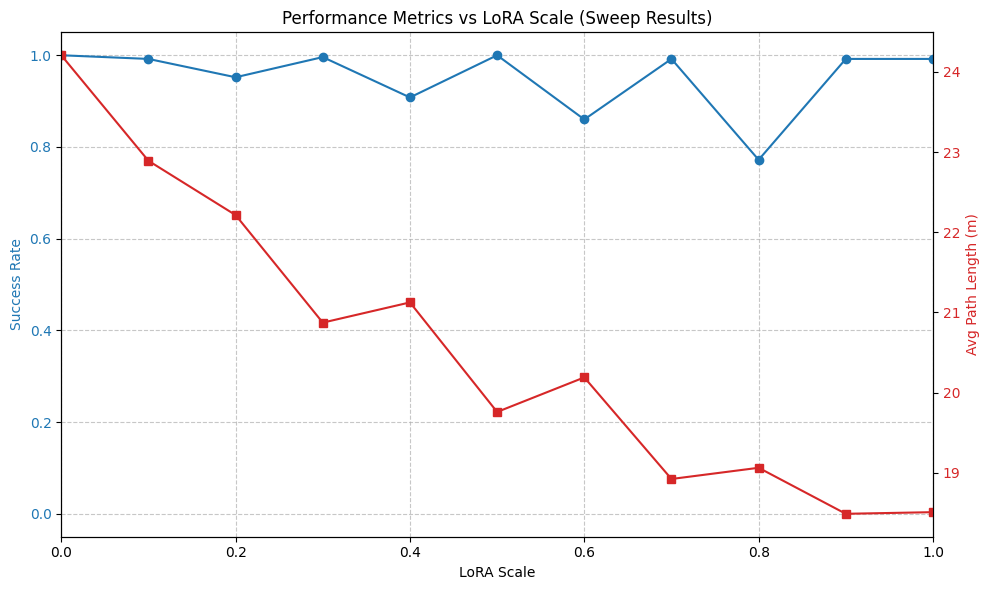

,lora_scale,success_rate,avg_path_length,total_episodes
9,0.0,1.000,24.206217,500
11,0.1,0.992,22.890723,500
2,0.2,0.952,22.214162,500
3,0.3,0.996,20.873358,500
4,0.4,0.908,21.125549,500
12,0.5,1.000,19.760091,500
5,0.6,0.860,20.190971,500
0,0.7,0.992,18.924640,500
8,0.8,0.772,19.064270,500
1,0.9,0.992,18.490772,500


In [53]:
import glob
import re

# Settings
# Bumped from 50 to 400 to filter accidental partial-overwrite files
# (e.g. evaluation_data_scale_1.0.csv with only 200 ep when neighbours
# have 500 — that spike at scale=1.0 was a sample-size artifact, not a
# real performance dip).
min_episodes = 400

# Find all scale-specific CSV files in the test directory
csv_files = glob.glob(os.path.join(model_dir, 'evaluation_data_scale_*.csv'))
results = []

for csv_path in csv_files:
    match = re.search(r'evaluation_data_scale_([\d\.]+)\.csv', os.path.basename(csv_path))
    if match:
        scale = float(match.group(1))
        df = pd.read_csv(csv_path)
        
        # Calculate counts accurately (matching plot_lora_results.py)
        successes = df['Success Times'].count()
        collisions = df['Collision Times'].count()
        timeouts = df['Timeout Times'].count()
        total = successes + collisions + timeouts
        
        if total < min_episodes:
            print(f"Skipping scale {scale}: Only {total} episodes (min_episodes={min_episodes})")
            continue

        results.append({
            'lora_scale': scale,
            'success_rate': successes / total,
            'avg_path_length': df['Path Length'].mean(),
            'total_episodes': total
        })

if results:
    df_sweep = pd.DataFrame(results).sort_values(by='lora_scale')
    # Clamp x-axis range to [0, 1]: scales outside that interval are
    # sweep stress-tests, not the operating range — exclude them so
    # the plot focuses on what's behaviourally meaningful.
    df_sweep = df_sweep[(df_sweep['lora_scale'] >= 0.0) & (df_sweep['lora_scale'] <= 1.0)]
    
    # Prepare lists for dual-axis plotting (matching plot_lora_results.py style)
    scales = df_sweep['lora_scale'].tolist()
    sr = df_sweep['success_rate'].tolist()
    pl = df_sweep['avg_path_length'].tolist()
    
    # Dual axis plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel('LoRA Scale')
    ax1.set_ylabel('Success Rate', color=color)
    ax1.plot(scales, sr, 'o-', color=color, label='Success Rate')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.05, 1.05)
    ax1.set_xlim(0.0, 1.0)
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Avg Path Length (m)', color=color)
    ax2.plot(scales, pl, 's-', color=color, label='Avg Path Length')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Performance Metrics vs LoRA Scale (Sweep Results)')
    fig.tight_layout()
    plt.show()
    
    display(df_sweep[['lora_scale', 'success_rate', 'avg_path_length', 'total_episodes']])
else:
    print("No valid scale-specific CSV data found in ", model_dir)

## 3. DAgger Convergence — Single-Panel View (hn=20 adaptive)

One plot, two lines:
- **Solid blue**: closed-loop AwAcc averaged across the 4 scenarios, evolving from `pre-DAgger` → `iter 1` → `iter 2` → `iter 3`. Each point uses the predictor as it stood at the start of that iteration.
- **Dashed green**: offline reference (no distribution shift) = the mean per-scenario val accuracy from `friendly_predictor_metrics.json`. This is the best the predictor can do on its own training distribution.

Light dots show per-scenario AwAcc at each iter (transparency for spread).

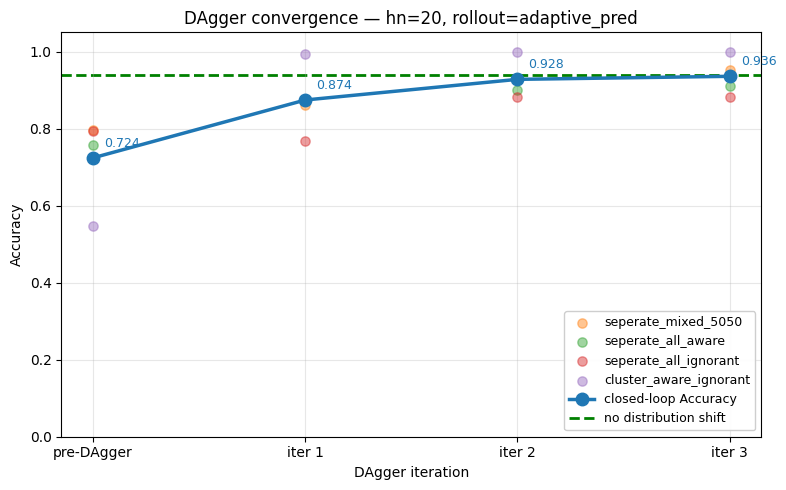

,pre-DAgger,iter 1,iter 2,iter 3
scenario,,,,
seperate_mixed_5050,0.797190,0.860498,0.930202,0.951732
seperate_all_aware,0.758564,0.875095,0.900034,0.911381
seperate_all_ignorant,0.793338,0.768924,0.881495,0.880835
cluster_aware_ignorant,0.547583,0.992708,1.000000,0.999240
(reference: val mean),NaN,NaN,NaN,0.940347


In [54]:
# Inline single-panel DAgger convergence plot (hn=20 adaptive only).
import glob, re
import pandas as pd

human_num = 20            # fixed for this single-plot view
rollout_driver = "adaptive"

SCENARIOS_PLOT = [
    "seperate_mixed_5050",
    "seperate_all_aware",
    "seperate_all_ignorant",
    "cluster_aware_ignorant",
]

def _summary_head_jp(path, peek=32768):
    if not os.path.exists(path): return None
    with open(path, 'rb') as fh:
        head = fh.read(peek)
    out = {}
    for k in ('tp','tn','fp','fn'):
        m = re.search(rb'"%s"\s*:\s*(\d+)' % k.encode(), head)
        if m: out[k] = int(m.group(1))
    return out

def _aw_acc(s):
    if not s: return None
    tp = s.get('tp', 0); tn = s.get('tn', 0); fp = s.get('fp', 0); fn = s.get('fn', 0)
    total = tp + tn + fp + fn
    return (tp + tn) / total if total > 0 else None

_test = model_dir  # 'trained_models/.../test/'

# Legacy hn=20 + adaptive DAgger dumps follow expdagger{N}.json convention.
# Iter N's rollout used the predictor BEFORE iter N's retrain (so expdagger1
# = pre-DAgger predictor, expdagger2 = after 1 retrain, etc.).
FILE_PER_ITER = {
    0: '{sc}_adaptive_pred_expdagger1.json',   # pre-DAgger
    1: '{sc}_adaptive_pred_expdagger2.json',   # after 1 retrain
    2: '{sc}_adaptive_pred_expdagger3.json',   # after 2 retrains
    3: '{sc}_adaptive_pred.json',              # final = after 3 retrains
}
ITER_LABELS = ['pre-DAgger', 'iter 1', 'iter 2', 'iter 3']

# Per-iter, per-scenario accuracy
per_iter = {it: {} for it in range(4)}
for it, pattern in FILE_PER_ITER.items():
    for sc in SCENARIOS_PLOT:
        path = os.path.join(_test, pattern.format(sc=sc))
        aw = _aw_acc(_summary_head_jp(path))
        if aw is not None:
            per_iter[it][sc] = aw

# Mean across scenarios per iter (only over scenarios with data at that iter)
import numpy as np
iters_with_data = [it for it in range(4) if per_iter[it]]
means = [np.mean(list(per_iter[it].values())) for it in iters_with_data]
ns    = [len(per_iter[it]) for it in iters_with_data]

# Offline (no distribution shift) reference from the predictor's metrics sidecar
metrics_path = os.path.join(_test, '..', 'friendly_predictor_metrics.json')
metrics_path = os.path.normpath(metrics_path)
ref = None
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        m = json.load(f)
    ref = m.get('mean_scenario_acc')

# Single-panel plot
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap('tab10')

# Per-scenario scatter (light)
for sc_idx, sc in enumerate(SCENARIOS_PLOT):
    xs, ys = [], []
    for it in range(4):
        if sc in per_iter[it]:
            xs.append(it); ys.append(per_iter[it][sc])
    if xs:
        ax.scatter(xs, ys, color=cmap(sc_idx+1), alpha=0.45, s=45,
                   label=sc, zorder=2)

# Mean line
ax.plot(iters_with_data, means, 'o-', color=cmap(0), linewidth=2.5, markersize=9,
        label='closed-loop Accuracy', zorder=3)
for x, y, n in zip(iters_with_data, means, ns):
    ax.annotate(f'{y:.3f}', (x, y),
                textcoords='offset points', xytext=(8, 8), fontsize=9,
                color=cmap(0))

# No-shift reference
if ref is not None:
    ax.axhline(ref, color='green', linestyle='--', linewidth=2,
               label='no distribution shift', zorder=1)

ax.set_xticks(range(4))
ax.set_xticklabels(ITER_LABELS)
ax.set_xlabel('DAgger iteration')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.0, 1.05)
ax.set_title(f'DAgger convergence — hn={human_num}, rollout={rollout_driver}_pred')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

# Table underneath: per-scenario accuracy at each iter
rows = []
for sc in SCENARIOS_PLOT:
    row = {'scenario': sc}
    for it, lbl in enumerate(ITER_LABELS):
        row[lbl] = per_iter[it].get(sc)
    rows.append(row)
if ref is not None:
    rows.append({'scenario': '(reference: val mean)', **{l: None for l in ITER_LABELS[:-1]}, ITER_LABELS[-1]: ref})
display(pd.DataFrame(rows).set_index('scenario'))

## 3.5 Awareness Predictor Metrics — Per-Behaviour Table

Companion to the DAgger convergence plot above. Each row is one *(scenario, behaviour)* pair; columns are awareness-classification metrics computed from the shadow-eval `tp/tn/fp/fn` counters in `all_evaluations.json`. The best value per column is **bolded**. The final `Mean` row per behaviour averages the four ratio metrics across scenarios.

- **AwAcc** = (TP+TN) / (TP+TN+FP+FN)
- **AwF1**  = 2 · Prec · Rec / (Prec + Rec)
- **AwPrec** = TP / (TP+FP)
- **AwRec**  = TP / (TP+FN)

Behaviours where the predictor doesn't run in shadow mode (i.e. no confusion-matrix counters were recorded) will show `NaN`.

In [55]:
# Awareness-predictor metrics table.
# Reuses df_combined from section 1 — no extra I/O.
import numpy as np

_AW_COLS = ['Scenario', 'Behavior', 'AwAcc', 'AwF1', 'TP', 'TN', 'FP', 'FN']
_aw = df_combined[_AW_COLS].copy()

# Numeric coercion (TP/TN/FP/FN come in as Python ints; AwAcc/AwF1 may be NaN).
for col in ['TP', 'TN', 'FP', 'FN']:
    _aw[col] = pd.to_numeric(_aw[col], errors='coerce').fillna(0).astype(int)

def _safe_div(num, den):
    return np.where(den > 0, num / np.where(den == 0, 1, den), np.nan)

_aw['AwPrec'] = _safe_div(_aw['TP'].to_numpy(), (_aw['TP'] + _aw['FP']).to_numpy())
_aw['AwRec']  = _safe_div(_aw['TP'].to_numpy(), (_aw['TP'] + _aw['FN']).to_numpy())

# Per-behaviour Mean row (only over ratio metrics; summing confusion counts
# would just be a duplicate of the totals so we leave TP/TN/FP/FN blank).
_means = (_aw.groupby('Behavior', sort=False)[['AwAcc', 'AwF1', 'AwPrec', 'AwRec']]
              .mean()
              .reset_index())
_means['Scenario'] = 'Mean'
for col in ['TP', 'TN', 'FP', 'FN']:
    _means[col] = np.nan

# Canonical ordering: behaviours in the order they appear in cell 3, with
# 'Mean' pinned to the end of each behaviour group.
_behavior_order = behaviors  # from cell 3
_scenario_order = scenarios + ['Mean']  # from cell 1

_tbl = pd.concat([_aw, _means], ignore_index=True)
_tbl['Behavior'] = pd.Categorical(_tbl['Behavior'], categories=_behavior_order, ordered=True)
_tbl['Scenario'] = pd.Categorical(_tbl['Scenario'], categories=_scenario_order, ordered=True)
_tbl = _tbl.sort_values(['Behavior', 'Scenario']).reset_index(drop=True)
_tbl = _tbl[['Behavior', 'Scenario', 'AwAcc', 'AwF1', 'AwPrec', 'AwRec', 'TP', 'TN', 'FP', 'FN']]
_tbl = _tbl.set_index(['Behavior', 'Scenario'])

# Style: 3-decimal ratios, integer counts, bold the best cell per ratio column.
_ratio_cols = ['AwAcc', 'AwF1', 'AwPrec', 'AwRec']
_count_cols = ['TP', 'TN', 'FP', 'FN']

_styled = (_tbl.style
              .format({c: '{:.3f}' for c in _ratio_cols}, na_rep='—')
              .format({c: '{:.0f}' for c in _count_cols}, na_rep='—')
              .highlight_max(subset=_ratio_cols, props='font-weight: bold;', axis=0)
              .set_caption('Awareness predictor metrics per (behaviour, scenario). '
                           'Bold = column-wise best.'))

print('### Per-behaviour awareness metrics')
display(_styled)

# Compact companion view: Mean-only rows, ranked by AwF1, with column-wise bolding
# restricted to the mean rows so the "best behaviour overall" is obvious.
_mean_only = _tbl.xs('Mean', level='Scenario')
_mean_styled = (_mean_only.style
                   .format({c: '{:.3f}' for c in _ratio_cols}, na_rep='—')
                   .format({c: '{:.0f}' for c in _count_cols}, na_rep='—')
                   .highlight_max(subset=_ratio_cols, props='font-weight: bold;', axis=0)
                   .set_caption('Mean across scenarios per behaviour. '
                                'Bold = best behaviour for that metric.'))
print('\n### Mean across scenarios (one row per behaviour)')
display(_mean_styled)

### Per-behaviour awareness metrics



### Mean across scenarios (one row per behaviour)


,AwAcc,AwF1,AwPrec,AwRec,TP,TN,FP,FN
Behavior,,,,,,,,
always_off,—,—,—,—,—,—,—,—
always_on,—,—,—,—,—,—,—,—
switching_gt,—,—,—,—,—,—,—,—
adaptive_gt,—,—,—,—,—,—,—,—
adaptive_pred,0.935797,0.726008,0.735923,0.956188,—,—,—,—


## 4. Policy Training Progress — LoraF rank 1 vs LoraF rank 4 vs Fulltune

Reward, success rate, and path length over training timesteps for the three main policy variants:
- **LoraF rank=1** — `trained_models/LoraF_invi_visi_rank_1` (rank-1 LoRA adapter on the SRNN+GST base)
- **LoraF rank=4** — `trained_models/LoraF_invi_visi_rank_4` (rank-4 LoRA adapter, more capacity)
- **Fulltune** — `trained_models/Fulltune2_invi_visi` (all weights trained end-to-end, no LoRA — same invi→visi curriculum)

Curves are smoothed with a 10-row rolling mean. Edit `progress_models` below to swap in different model directories.

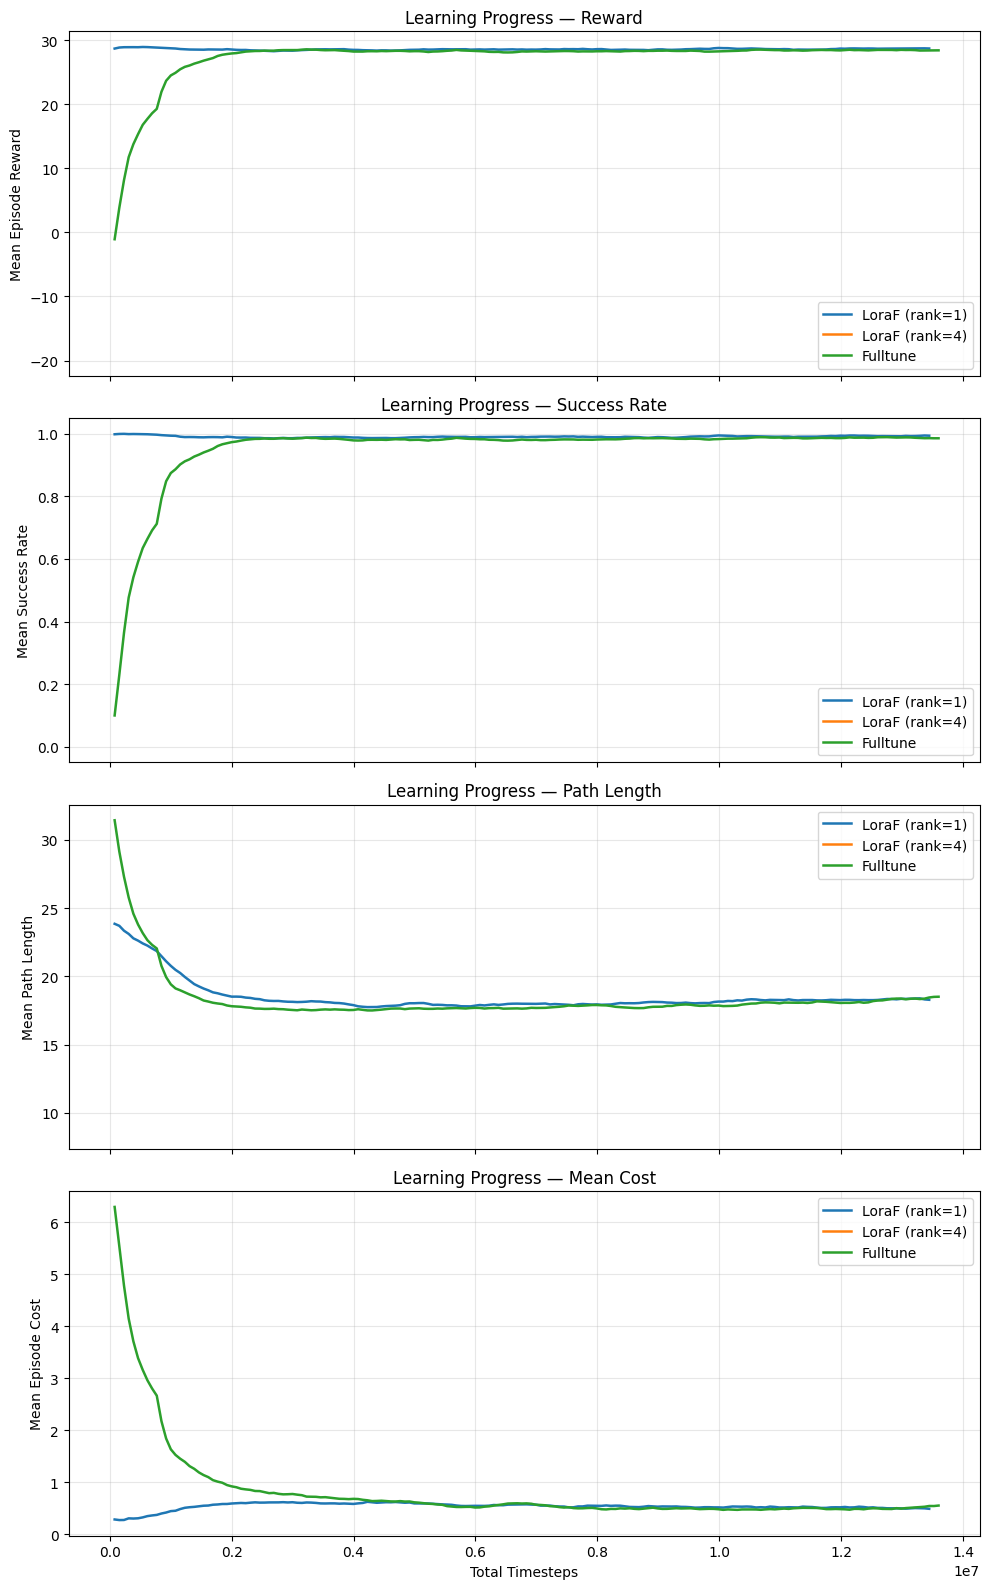

In [56]:
# Policy training progress — compare LoraF rank 1 / rank 4 / Fulltune.
# Reads progress.csv from each model dir. Adds a Mean Cost panel
# (epcostmean) alongside Reward / SR / PL.
import pandas as pd

progress_models = [
    {'path': 'trained_models/LoraF_invi_visi_rank_1', 'name': 'LoraF (rank=1)'},
    {'path': 'trained_models/LoraF_invi_visi_rank_4', 'name': 'LoraF (rank=4)'},
    {'path': 'trained_models/Fulltune2_invi_visi',    'name': 'Fulltune'},
]
window_size = 10  # rolling-mean window over csv rows

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 16), sharex=True)
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
found_any = False

for i, cfg in enumerate(progress_models):
    progress_file = os.path.join(cfg['path'], 'progress.csv')
    if not os.path.exists(progress_file):
        print(f'  skip: {progress_file} not found')
        continue
    try:
        df = pd.read_csv(progress_file)
    except Exception as e:
        print(f'  skip: error reading {progress_file}: {e}')
        continue
    if 'misc/total_timesteps' not in df.columns:
        print(f"  skip: 'misc/total_timesteps' missing in {cfg['name']}")
        continue
    x = df['misc/total_timesteps']
    color = colors[i % len(colors)]

    def _plot_col(ax, candidates, ylabel):
        for col in candidates:
            if col in df.columns:
                ax.plot(x, df[col].rolling(window_size, min_periods=1).mean(),
                        label=cfg['name'], color=color, linewidth=1.8)
                return True
        return False

    if _plot_col(ax1, ['eprewmean', 'reward', 'Mean Reward'], 'Mean Reward'):
        found_any = True
    _plot_col(ax2, ['epsuccessmean', 'success_rate', 'Success Rate'], 'Success Rate')
    _plot_col(ax3, ['eppathlengthmean', 'path_length', 'Path Length'], 'Path Length')
    _plot_col(ax4, ['epcostmean', 'cost', 'Mean Cost'], 'Mean Cost')

if not found_any:
    print('No data plotted.')
else:
    ax1.set_ylabel('Mean Episode Reward'); ax1.set_title('Learning Progress — Reward')
    ax1.legend(loc='lower right'); ax1.grid(True, alpha=0.3)
    ax2.set_ylabel('Mean Success Rate'); ax2.set_title('Learning Progress — Success Rate')
    ax2.legend(loc='lower right'); ax2.grid(True, alpha=0.3); ax2.set_ylim(-0.05, 1.05)
    ax3.set_ylabel('Mean Path Length'); ax3.set_title('Learning Progress — Path Length')
    ax3.legend(loc='upper right'); ax3.grid(True, alpha=0.3)
    ax4.set_ylabel('Mean Episode Cost'); ax4.set_title('Learning Progress — Mean Cost')
    ax4.set_xlabel('Total Timesteps')
    ax4.legend(loc='upper right'); ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Awareness Predictor Training Progress

Per-epoch val accuracy of the FriendlyPredictor, broken out per scenario, concatenated across DAgger iterations. Reads each `friendly_predictor_history_*_iter{N}.json` written by `train_alpha_from_json.py` / `dagger_loop.py`.

Adjust `predictor_tag` below to switch which DAgger sweep you're inspecting (e.g. `h20_adaptive`, `h30_switching`). Solid lines = per-scenario val accuracy; the bold dashed line = min-over-scenarios (the checkpoint-selection metric). Vertical dotted lines mark iteration boundaries.

Loading 3 history file(s) for h20_adaptive:
  friendly_predictor_history_h20_adaptive_iter1.json
  friendly_predictor_history_h20_adaptive_iter2.json
  friendly_predictor_history_h20_adaptive_iter3.json


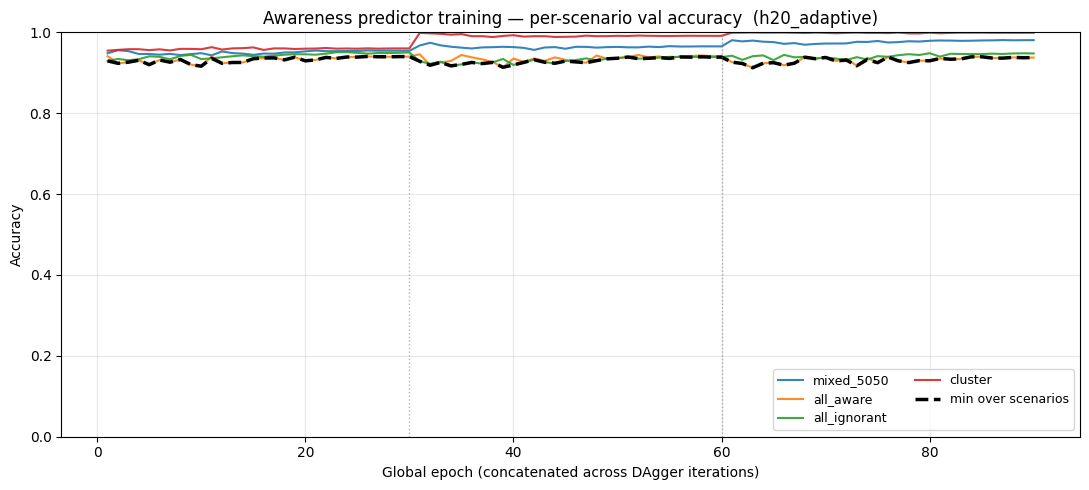

In [57]:
# Awareness predictor training progress — inline version of plot_awareness_training.py
import glob, re
import pandas as pd

predictor_tag = 'h20_adaptive'   # change to 'h30_adaptive' / 'h40_adaptive' etc.

pred_dir = os.path.dirname(model_dir.rstrip('/'))
pattern = os.path.join(pred_dir, f'friendly_predictor_history_{predictor_tag}_iter*.json')
history_paths = sorted(glob.glob(pattern), key=lambda p: int(re.search(r'_iter(\d+)\.json$', p).group(1)))

if not history_paths:
    # Fall back to the canonical (untagged) single-training history file.
    fallback = os.path.join(pred_dir, 'friendly_predictor_history.json')
    if os.path.exists(fallback):
        history_paths = [fallback]

if not history_paths:
    print(f'No history files found for predictor_tag={predictor_tag!r} in {pred_dir}/')
    print('Available history files:')
    for f in sorted(glob.glob(os.path.join(pred_dir, 'friendly_predictor_*history*.json'))):
        print(f'  {os.path.basename(f)}')
else:
    print(f'Loading {len(history_paths)} history file(s) for {predictor_tag}:')
    for p in history_paths:
        print(f'  {os.path.basename(p)}')

    histories = [json.load(open(p)) for p in history_paths]
    # Stable, ordered union of scenario names across all history files.
    seen = []
    for h in histories:
        for sc in h.get('scenarios', []):
            if sc not in seen: seen.append(sc)
        for ep in h.get('history', []):
            for sc in ep.get('per_scenario', {}).keys():
                if sc not in seen: seen.append(sc)
    sc_list = seen

    # Build per-scenario series + iteration boundaries (global epoch axis)
    series = {sc: ([], []) for sc in sc_list}
    min_xs, min_ys = [], []
    epoch_offset = 0
    boundaries = []
    for h in histories:
        eps = h.get('history', [])
        for ep in eps:
            ep_idx = epoch_offset + ep['epoch']
            per_sc = ep.get('per_scenario', {})
            for sc in sc_list:
                if sc in per_sc and 'acc' in per_sc[sc]:
                    series[sc][0].append(ep_idx); series[sc][1].append(per_sc[sc]['acc'])
            if 'min_scenario_acc' in ep:
                min_xs.append(ep_idx); min_ys.append(ep['min_scenario_acc'])
        if eps:
            epoch_offset += int(eps[-1]['epoch'])
            boundaries.append(epoch_offset)

    # Plot
    fig, ax = plt.subplots(figsize=(11, 5))
    cmap = plt.get_cmap('tab10')
    for i, sc in enumerate(sc_list):
        xs, ys = series[sc]
        if xs:
            ax.plot(xs, ys, color=cmap(i), label=sc, linewidth=1.5, alpha=0.9)
    if min_xs:
        ax.plot(min_xs, min_ys, color='black', label='min over scenarios',
                linewidth=2.5, linestyle='--')
    for b in boundaries[:-1]:
        ax.axvline(b, color='gray', linestyle=':', alpha=0.6, linewidth=1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel('Global epoch (concatenated across DAgger iterations)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Awareness predictor training — per-scenario val accuracy  ({predictor_tag})')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

## 6. Fixed-α Scale Sweep vs Adaptive — Scenario-Averaged Comparison

For one LoRA model, averages SR / PL / ITR / SD across all scenarios at each fixed LoRA α (from the `test_lora_ablation.sh` output) and stacks the adaptive_gt / adaptive_pred rows for direct comparison. The point of this table is to answer: *what's the best fixed α, and how does it compare to letting the predictor / GT decide α dynamically?*

Rows are the α settings (or adaptive variants); columns are the four averaged metrics with ± over scenarios (cross-scenario std).

In [ ]:
# Fixed-scale sweep vs adaptive — scenario-averaged comparison table
import pandas as pd
import numpy as np
import math

model_dir_for_sweep = f'trained_models/{model_name}'  # uses notebook's model_name
scenarios_internal = ['seperate_mixed_5050', 'seperate_all_aware',
                      'seperate_all_ignorant', 'cluster_aware_ignorant']
# scenarios_internal = ['seperate_all_ignorant']
scales = [0.2, 0.4, 0.6, 0.8, 1.0]
adaptive_variants = ['adaptive_gt', 'adaptive_pred']
scale_seed_suffix = ''   # set to e.g. '_seed7' if you ran a second-seed ablation with --exp seed7
adaptive_exp_suffix = ''  # set to '_exp10' to use the _exp10 adaptive runs

agg_path = os.path.join(model_dir_for_sweep, 'test', 'all_evaluations.json')
if not os.path.exists(agg_path):
    print(f'No aggregate at {agg_path}')
else:
    with open(agg_path) as f:
        aggregate = json.load(f)

    def _row_for_key_pattern(label, keys_for_each_scenario, agg=None):
        """Average SR/CR/NT/PL/ITR/SD/AwAcc across scenarios for the given keys.
        agg defaults to the main `aggregate` (LoraF model_dir) but can be
        any other model_dir's all_evaluations.json (e.g. for the naive
        baseline pulled from Fulltune_random_visi_seed_42)."""
        if agg is None:
            agg = aggregate
        srs, crs, nts, pls, itrs, sds, awaccs = [], [], [], [], [], [], []
        ns = []
        for sc, key in zip(scenarios_internal, keys_for_each_scenario):
            ent = agg.get(key)
            if ent is None:
                continue
            s = ent.get('summary', {})
            ns.append(s.get('num_episodes', 0) or 0)
            srs.append(s.get('success_rate'))
            crs.append(s.get('collision_rate'))
            nts.append(s.get('avg_nav_time'))
            pls.append(s.get('avg_path_length'))
            itrs.append(s.get('avg_intrusion_ratio_pct'))
            sds.append(s.get('avg_min_social_distance'))
            tp = s.get('tp', 0) or 0; tn = s.get('tn', 0) or 0
            fp = s.get('fp', 0) or 0; fn = s.get('fn', 0) or 0
            tot = tp + tn + fp + fn
            awaccs.append((tp + tn) / tot if tot > 0 else float('nan'))
        def _mean(xs):
            xs = [x for x in xs if x is not None and not (isinstance(x, float) and math.isnan(x))]
            return float(np.mean(xs)) if xs else float('nan')
        def _std(xs):
            xs = [x for x in xs if x is not None and not (isinstance(x, float) and math.isnan(x))]
            return float(np.std(xs, ddof=1)) if len(xs) > 1 else float('nan')
        return {
            'Setting': label,
            'SR_mean':  _mean(srs),  'SR_SD':  _std(srs),
            'CR_mean':  _mean(crs),  'CR_SD':  _std(crs),
            'NT_mean':  _mean(nts),  'NT_SD':  _std(nts),
            'PL_mean':  _mean(pls),  'PL_SD':  _std(pls),
            'ITR_mean': _mean(itrs), 'ITR_SD': _std(itrs),
            'SD_mean':  _mean(sds),  'SD_SD':  _std(sds),
            'AwAcc_mean': _mean(awaccs), 'AwAcc_SD': _std(awaccs),
            'N_scenarios': len([x for x in srs if x is not None]),
        }

    rows = []
    # Fixed-α rows (from test_lora_ablation.sh's --exp_id=scale_X.X convention)
    for alpha in scales:
        keys = [f'{sc}_fixed_scale_expscale_{alpha}{scale_seed_suffix}'
                for sc in scenarios_internal]
        rows.append(_row_for_key_pattern(f'α = {alpha}', keys))
    # Adaptive rows (from test_adaptive_lora_poc.sh — default unsuffixed or _exp10)
    for beh in adaptive_variants:
        keys = [f'{sc}_{beh}{adaptive_exp_suffix}' for sc in scenarios_internal]
        rows.append(_row_for_key_pattern(beh, keys))

    # base conservative = always_off on the LoraF model (LoRA fully off =
    # base polite policy). Reads from the same LoraF aggregate.
    base_keys = [f'{sc}_always_off{adaptive_exp_suffix}' for sc in scenarios_internal]
    rows.append(_row_for_key_pattern('base (always_off)', base_keys))

    # naive = GenSafeNav-naive = a Fulltune SRNN+GST trained without LoRA.
    # Lives in a different model_dir so we load its own aggregate.
    naive_dir = 'trained_models/Fulltune_random_visi_seed_42'
    naive_agg_path = os.path.join(naive_dir, 'test', 'all_evaluations.json')
    if os.path.exists(naive_agg_path):
        with open(naive_agg_path) as nf:
            naive_agg = json.load(nf)
        naive_keys = [f'{sc}_always_off{adaptive_exp_suffix}' for sc in scenarios_internal]
        rows.append(_row_for_key_pattern('GenSafeNav-naive', naive_keys, agg=naive_agg))
    else:
        print(f'  [Section 6] {naive_agg_path} not found — skipping naive row.')
        print(f'  Run `./test_baselines.sh` with the GenSafeNav-naive line uncommented to populate it.')

    df_compare = pd.DataFrame(rows).set_index('Setting')
    print(f'### Scenario-averaged comparison  ({model_dir_for_sweep})')
    print(f'    Averaged across: {scenarios_internal}')
    print(f'    ± shown is cross-scenario std (variability across the 4 scenarios)')
    display(df_compare)

    # Compact formatted view
    def _fmt(m, s):
        if math.isnan(m): return '—'
        if math.isnan(s): return f'{m:.3f}'
        return f'{m:.3f} ± {s:.3f}'

    compact = pd.DataFrame({
        'SR':    [_fmt(r['SR_mean'],    r['SR_SD'])    for r in rows],
        'CR':    [_fmt(r['CR_mean'],    r['CR_SD'])    for r in rows],
        'NT':    [_fmt(r['NT_mean'],    r['NT_SD'])    for r in rows],
        'PL':    [_fmt(r['PL_mean'],    r['PL_SD'])    for r in rows],
        'ITR%':  [_fmt(r['ITR_mean'],   r['ITR_SD'])   for r in rows],
        'SD':    [_fmt(r['SD_mean'],    r['SD_SD'])    for r in rows],
        'AwAcc': [_fmt(r['AwAcc_mean'], r['AwAcc_SD']) for r in rows],
        'N_sc':  [r['N_scenarios'] for r in rows],
    }, index=[r['Setting'] for r in rows])
    compact.index.name = 'Setting'
    print('\nCompact view:')
    display(compact)